<a href="https://colab.research.google.com/github/eudoraa04/FreshCart/blob/main/aiml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

# Set random seed for reproducibility
np.random.seed(42)

# Generate dummy data for 1000 users
n_users = 1000

# Define exactly 7 columns focusing on loan details
data = {
    'User_ID': [f'USR_{i:04d}' for i in range(1, n_users + 1)],
    'Annual_Income_USD': np.random.randint(25000, 150000, size=n_users),
    'Credit_Score': np.random.randint(300, 850, size=n_users),
    'Loan_Amount_USD': np.random.randint(5000, 50000, size=n_users),
    'Loan_Term_Months': np.random.choice([12, 24, 36, 48, 60], size=n_users),
    'Existing_Debts_USD': np.random.randint(0, 20000, size=n_users),
    'Loan_Approved': np.zeros(n_users, dtype=int)  # Placeholder to be filled
}

df = pd.DataFrame(data)

# Create a rule-based logic to determine 'Loan_Approved'
# High credit score, higher income, and low debt/loan ratio increase approval probability
approval_score = (df['Credit_Score'] * 0.5) + (df['Annual_Income_USD'] / 1000 * 0.4) - (df['Loan_Amount_USD'] / 1000 * 0.2) - (df['Existing_Debts_USD'] / 1000 * 0.2)
threshold = approval_score.median()

# Set approval status (1: Approved, 0: Rejected)
df['Loan_Approved'] = (approval_score > threshold).astype(int)

# Display the shape and the first few rows of the dataset
print(f'Dataset shape: {df.shape}')
display(df.head())

Dataset shape: (1000, 7)


,User_ID,Annual_Income_USD,Credit_Score,Loan_Amount_USD,Loan_Term_Months,Existing_Debts_USD,Loan_Approved
0,USR_0001,146958,404,41487,12,166,0
1,USR_0002,40795,398,5302,36,508,0
2,USR_0003,25860,810,36463,48,18045,1
3,USR_0004,128694,684,49912,24,3664,1
4,USR_0005,144879,704,34259,12,19873,1


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Define features (X) and target (y)
# Excluding 'User_ID' as it's just an identifier
features = ['Annual_Income_USD', 'Credit_Score', 'Loan_Amount_USD', 'Loan_Term_Months', 'Existing_Debts_USD']
X = df[features]
y = df['Loan_Approved']

# Split into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Standardize features for logistic regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Logistic Regression model
model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)

# Predict on the test set
y_pred = model.predict(X_test_scaled)

# Print evaluation metrics
print('=== Logistic Regression Performance ===')
print(f'Accuracy: {accuracy_score(y_test, y_pred):.4f}\n')
print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred))
print('\nClassification Report:')
print(classification_report(y_test, y_pred))

# Display model coefficients to see feature importance
coefficients = pd.DataFrame({
    'Feature': features,
    'Coefficient': model.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

print('\nModel Coefficients:')
display(coefficients)

=== Logistic Regression Performance ===
Accuracy: 0.9900

Confusion Matrix:
[[99  1]
 [ 1 99]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       100
           1       0.99      0.99      0.99       100

    accuracy                           0.99       200
   macro avg       0.99      0.99      0.99       200
weighted avg       0.99      0.99      0.99       200


Model Coefficients:


,Feature,Coefficient
1,Credit_Score,7.194145
0,Annual_Income_USD,1.240915
3,Loan_Term_Months,0.169060
2,Loan_Amount_USD,-0.129657
4,Existing_Debts_USD,-0.226631


In [5]:
# @title Test Model with Custom Input
import numpy as np
import pandas as pd

# Define the input fields using Colab form annotations
Annual_Income_USD = 75000 #@param {type:"number"}
Credit_Score = 650 #@param {type:"slider", min:300, max:850, step:1}
Loan_Amount_USD = 20000 #@param {type:"number"}
Loan_Term_Months = 36 #@param [12, 24, 36, 48, 60] {type:"raw"}
Existing_Debts_USD = 5000 #@param {type:"number"}

# Create a DataFrame for the custom input
custom_data = pd.DataFrame({
    'Annual_Income_USD': [Annual_Income_USD],
    'Credit_Score': [Credit_Score],
    'Loan_Amount_USD': [Loan_Amount_USD],
    'Loan_Term_Months': [Loan_Term_Months],
    'Existing_Debts_USD': [Existing_Debts_USD]
})

# Scale the inputs using the fitted scaler
custom_scaled = scaler.transform(custom_data)

# Make predictions
prediction = model.predict(custom_scaled)[0]
probabilities = model.predict_proba(custom_scaled)[0]

# Display the prediction results
print("=== Custom Input Evaluation ===")
print(f"Annual Income: ${Annual_Income_USD:,.2f}")
print(f"Credit Score: {Credit_Score}")
print(f"Loan Amount: ${Loan_Amount_USD:,.2f}")
print(f"Loan Term: {Loan_Term_Months} months")
print(f"Existing Debts: ${Existing_Debts_USD:,.2f}")
print("-------------------------------")

if prediction == 1:
    print(f"🎉 Prediction: APPROVED (Confidence: {probabilities[1]*100:.2f}%)")
else:
    print(f"❌ Prediction: REJECTED (Confidence: {probabilities[0]*100:.2f}%)")

=== Custom Input Evaluation ===
Annual Income: $75,000.00
Credit Score: 650
Loan Amount: $20,000.00
Loan Term: 36 months
Existing Debts: $5,000.00
-------------------------------
🎉 Prediction: APPROVED (Confidence: 97.37%)


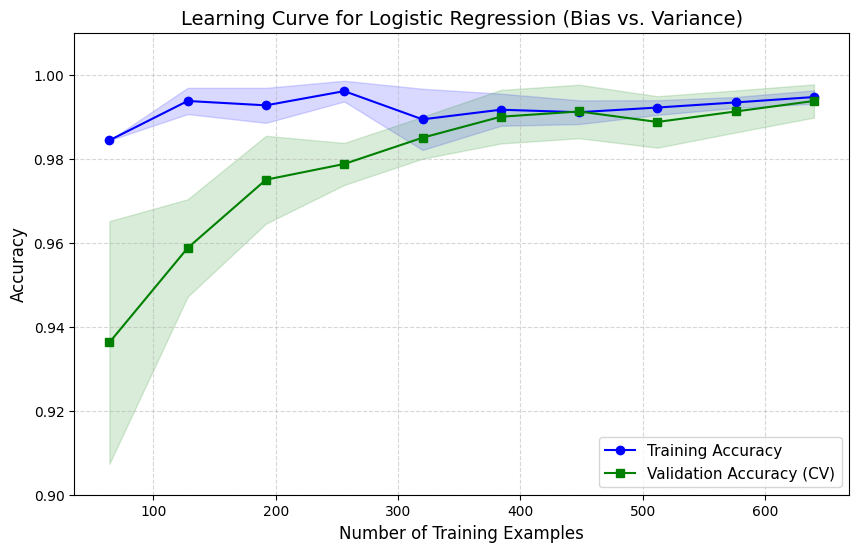

In [ ]:
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve

# Calculate learning curve data
train_sizes, train_scores, test_scores = learning_curve(
    estimator=model,
    X=X_train_scaled,
    y=y_train,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42
)

# Calculate mean and standard deviation for training and test scores
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# Plot the learning curve
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'o-', color='blue', label='Training Accuracy')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='blue')

plt.plot(train_sizes, test_mean, 's-', color='green', label='Validation Accuracy (CV)')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.15, color='green')

plt.title('Learning Curve for Logistic Regression (Bias vs. Variance)', fontsize=14)
plt.xlabel('Number of Training Examples', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='lower right', fontsize=11)
plt.ylim(0.9, 1.01)
plt.show()

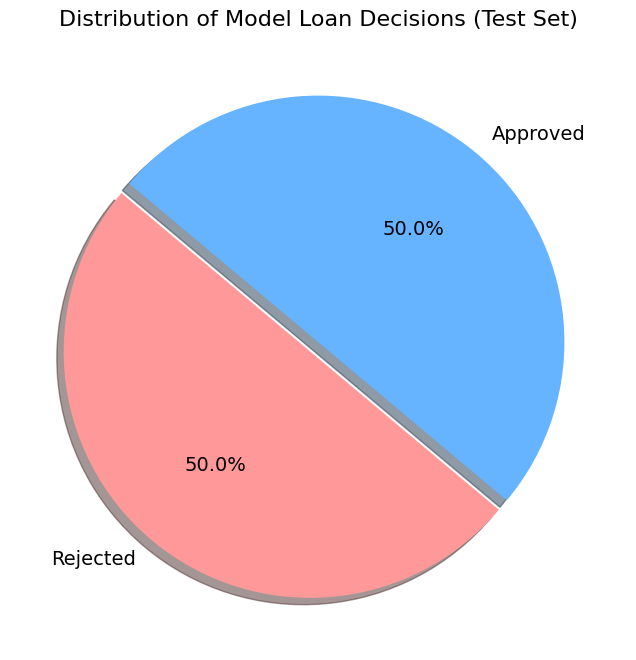

In [ ]:
import matplotlib.pyplot as plt

# Count the predicted approvals and rejections
unique, counts = np.unique(y_pred, return_counts=True)
pred_counts = dict(zip(unique, counts))

labels = ['Rejected', 'Approved']
sizes = [pred_counts.get(0, 0), pred_counts.get(1, 0)]
colors = ['#ff9999', '#66b3ff']
explode = (0.05, 0)  # slightly explode the 'Rejected' slice

# Plot the pie chart
plt.figure(figsize=(8, 8))
plt.pie(
    sizes,
    explode=explode,
    labels=labels,
    colors=colors,
    autopct='%1.1f%%',
    shadow=True,
    startangle=140,
    textprops={'fontsize': 14}
)

plt.title('Distribution of Model Loan Decisions (Test Set)', fontsize=16)
plt.show()